# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1.시계열 데이터를 통계적 방법을 통해 추정하는 경우 정상성,즉 데이터의 통계적 특성이 일정하다는 것을 가정하고 통계적 방법을 사용하기 때문에 추정의 정확도와 신뢰성을 위해 중요하다.
ARIMA모델은 차분을 통해 추세를 제거하는데 단한번의 차분뿐만이 아니라 추가적인 차분으로 비정상성을 처리한다

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2.acf는 정상이라면 빠르게 감소해야하는데 천천히 감소하므로 비정상 시계열이다.
1차 차분후 절단 형태를 보이므로 더이상 차분을 할 필요는 없고 pacf가 점진적으로 감소한다는 건 ma성분이 주로 사용됨을 말하므로 ARIMA(0,1,1)모형이 적절하다.

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [1]:
# kaggle 데이터 로드
import os

path = "/kaggle/input/weatherww2"
print(os.listdir(path))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/weatherww2'

In [3]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("Weather_Station_Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [6]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("Summary_of_Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_223/2601665569.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("Summary_of_Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [7]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_223/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_223/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


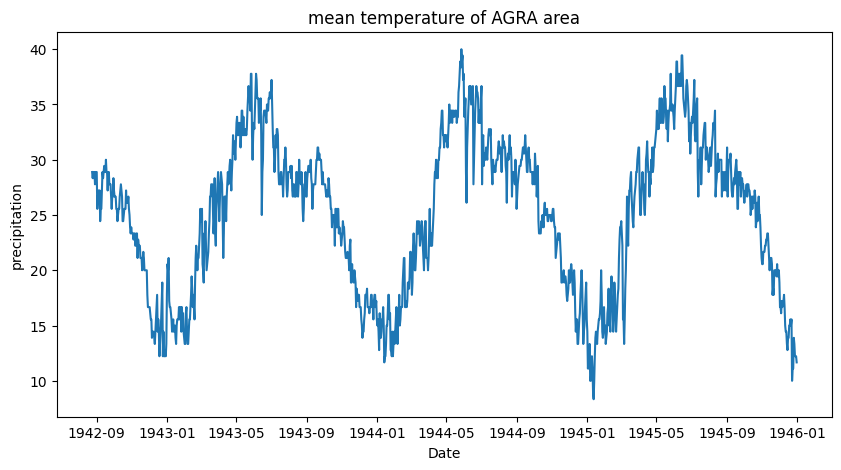

In [8]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [9]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

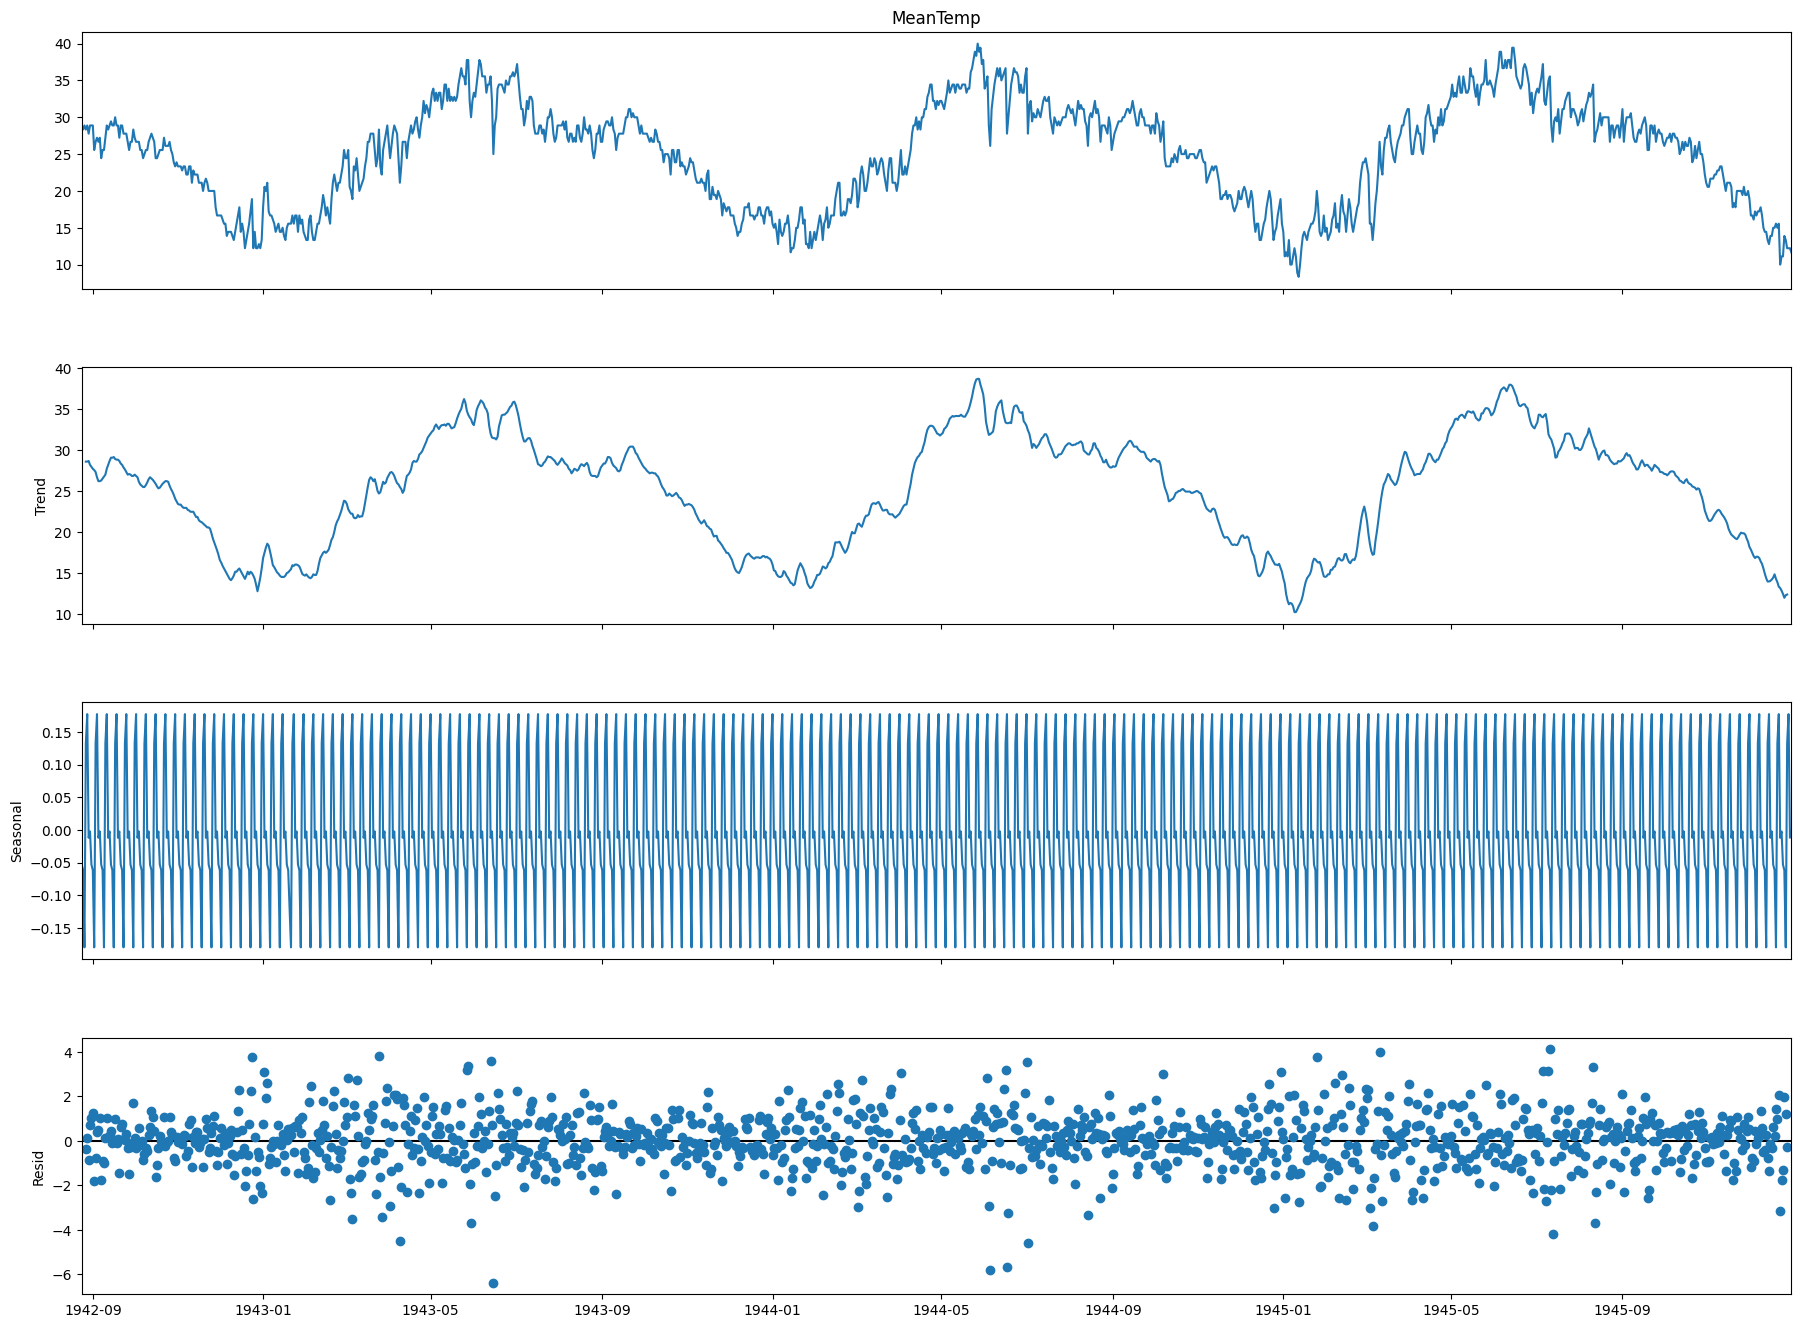

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

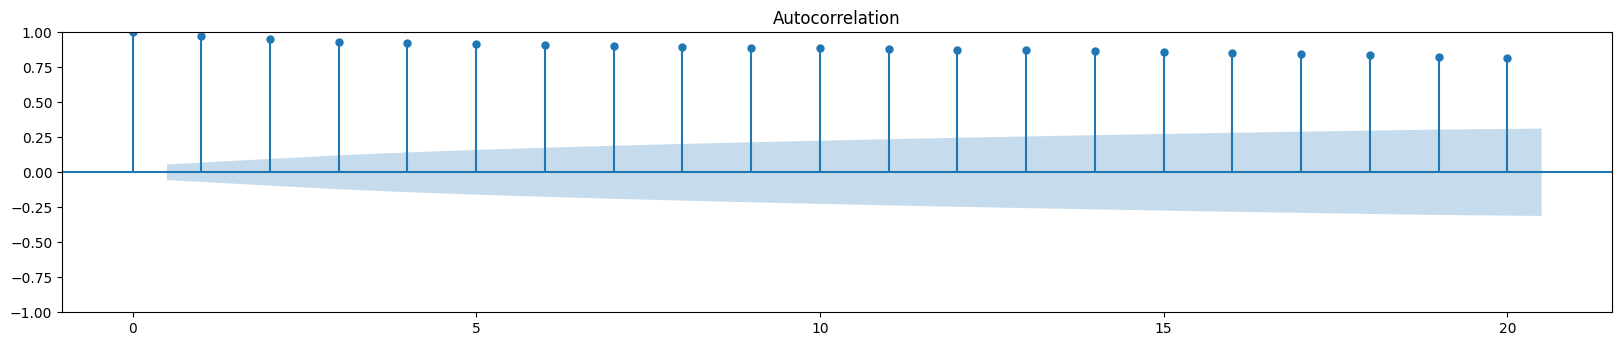

In [11]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [12]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1.adf검정 결과 비정상 시계열이다.
귀무가설은 비정상시계열이라는 것이고 대립가설은 정상 시계열이라는 것이다. 분석결과 p-value가 0.259885라는 유의수준 0.05보다 훨씬 큰 값이 나와 귀무가설을 기각하지 못해 비정상시계열이라는 것을 알 수 있다

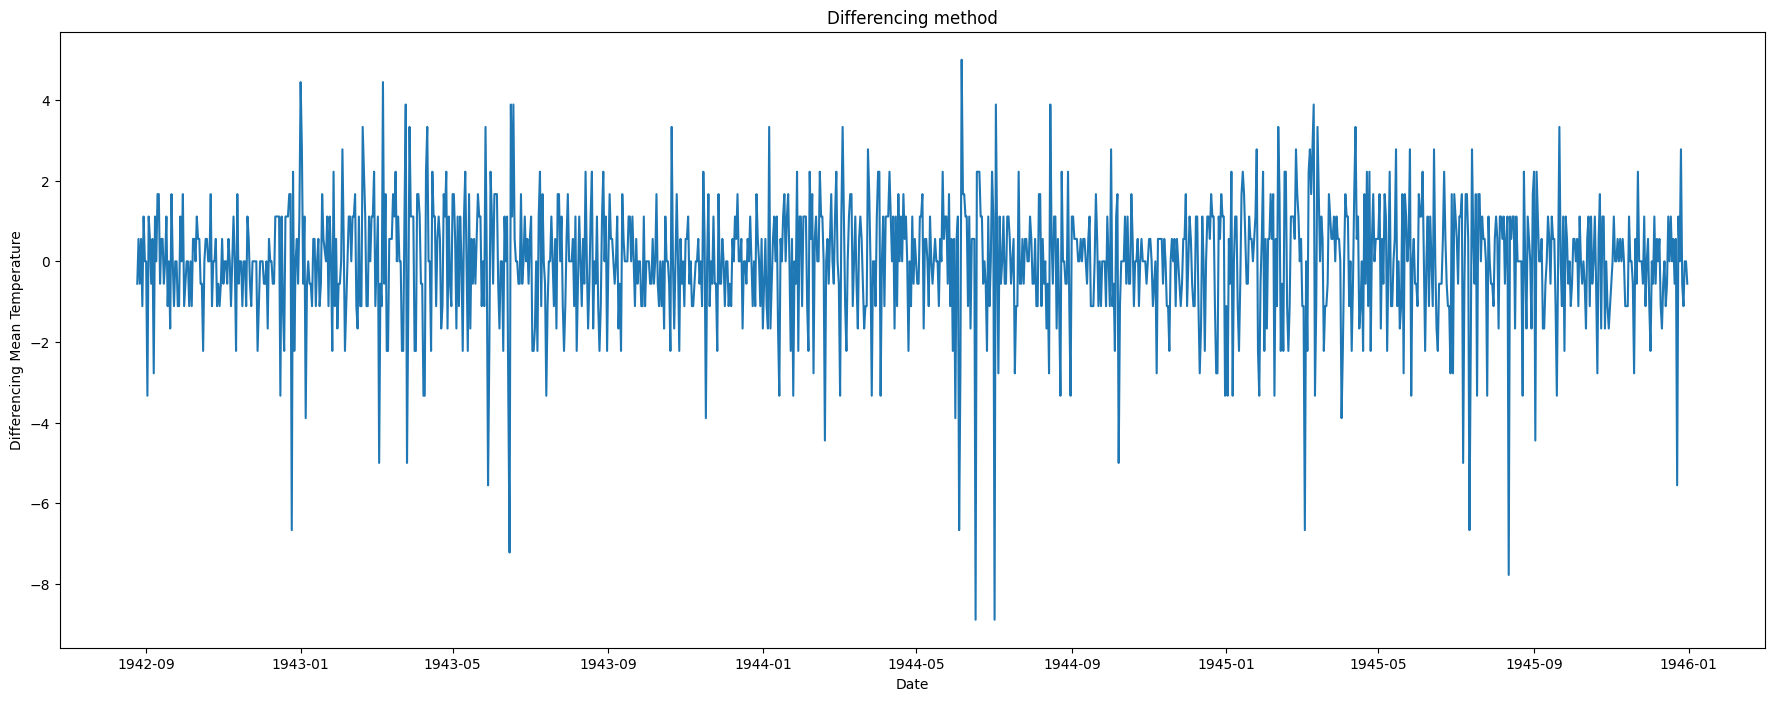

In [14]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [15]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2.p value가 0.05이하가 되어 귀무가설을 기각할 수 있고 이 시계열이 정상시계열임을 보여준다.이는 차분을 통해 비정상시계열을 정상시계열로 바꿨기 때문이다

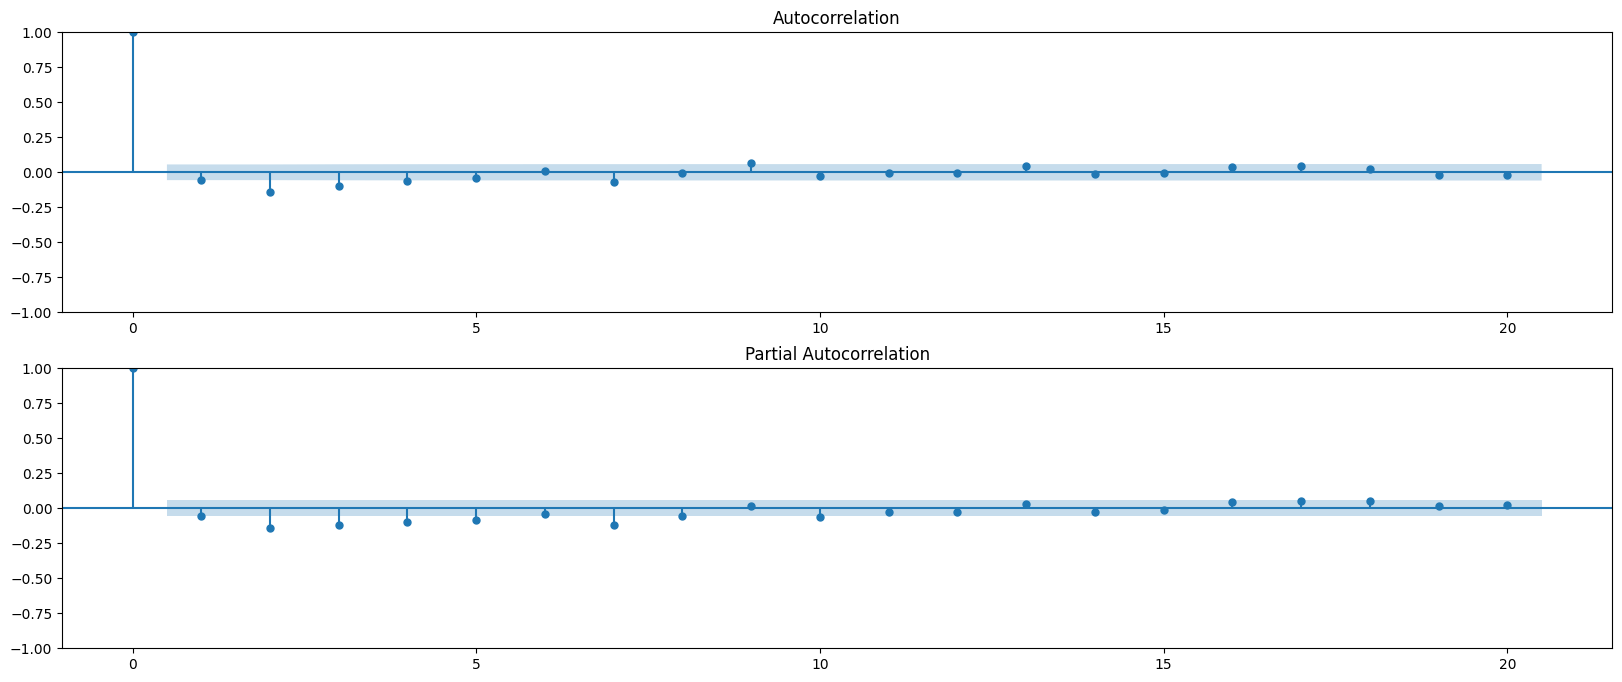

In [16]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.위의 그래프는 ACF,아래의 그래프는 PACF그래프이다.ACF그래프에서 값이 절단되고 PACF그래프는 전반적으로 값이 작아지며 없어지는 형태를 보이는데 이는 전형적인 MA 모형의 형태이므로 p=0이 적절하고 acf그래프에서 시차 2에서 신뢰구간을 벗어나고 이후는 다시 절단된 모습을 보이므로 q=2가 적절하다.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


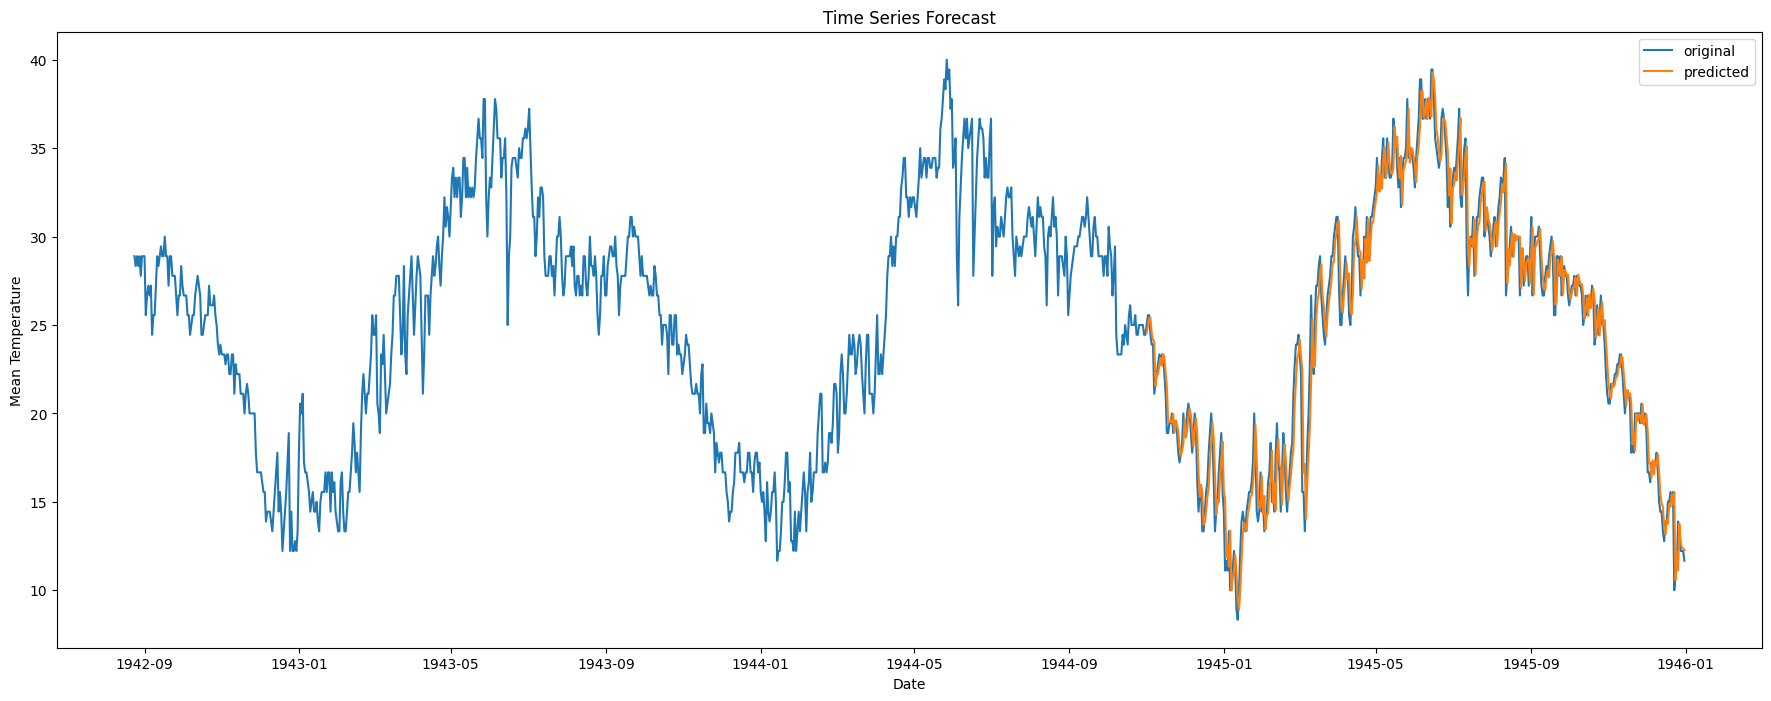

In [17]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p =0
d =1
q =2

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_223/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


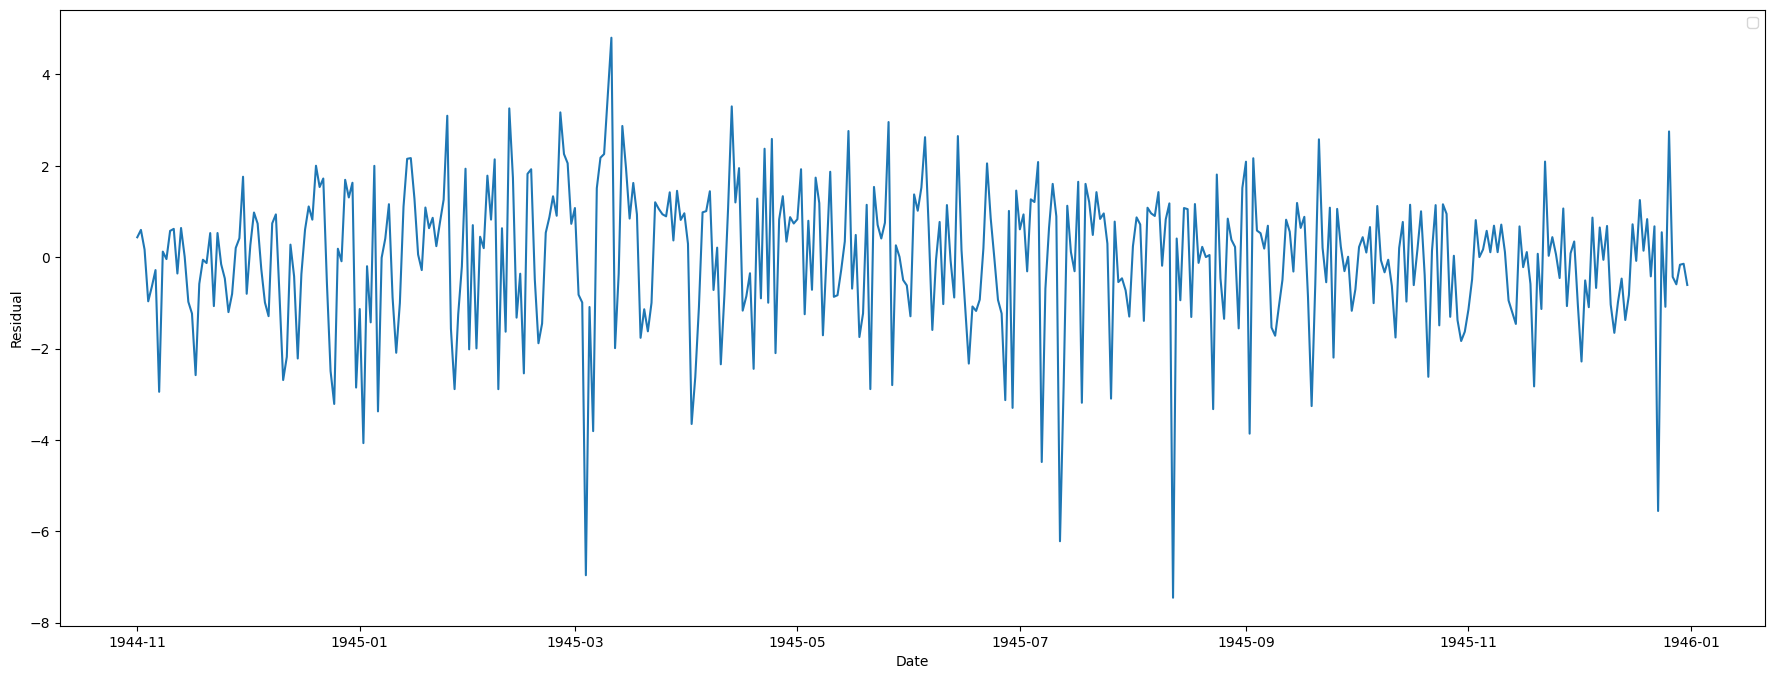

In [18]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

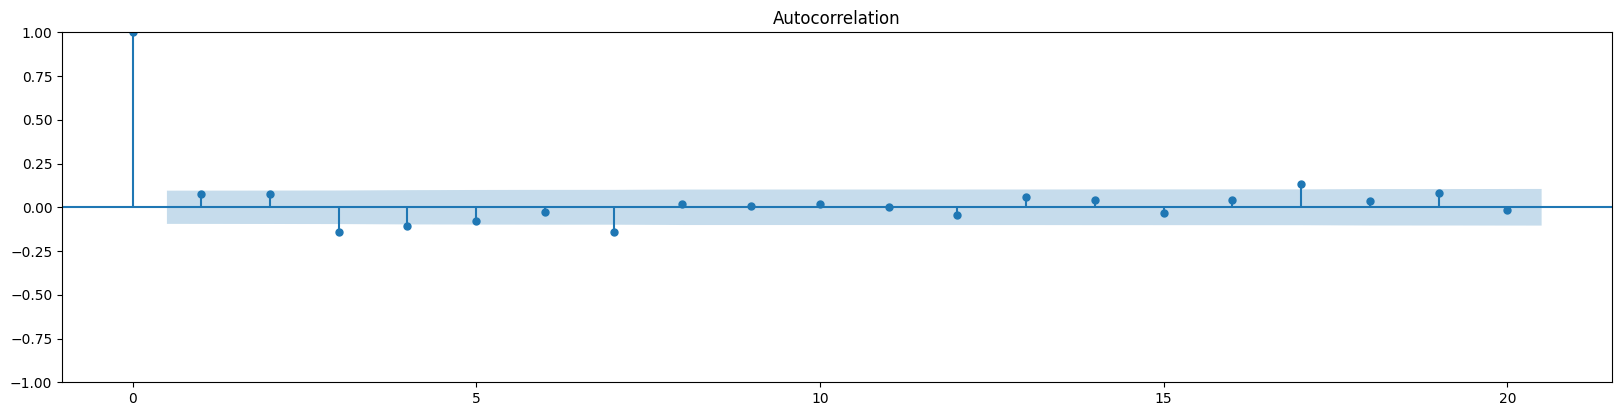

In [19]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [20]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.592822
p-value: 0.000133
Critical Values:
	1%: -3.446
	5%: -2.869
	10%: -2.571


In [22]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [23]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.617,0.978,1.555,5.475


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

*A4*. 만들어낸 모델이 데이터를 잘 설명하고 있음
r2 -> 모델이 데이터 변동의 95%를 설명하고 있음
corr -> 실제값과 예측값의 선형관계 강함
MAPE -> 오차율이 약 5%

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.kernel=365,epoch=10,learning rate=0.001
kernel은 해석력을 위해 튜닝을 고려하지 않았고 learning rate를 0.01 0.001 0.0001 로 바꿔가며 테스트 해봣을 때 0.001에서 오차율이 제일 낮았고 그 이후 epoch도 증가시켜봤는데 그냥 10에서 오차율이 제일 낮은 모습을 보였다.
ARIMA모델이 더 적합한 것 같다. 설명성이나 오차율,상관성등의 모든 지표에서 더 우월한 모습을 보인다.

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [35]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [36]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [53]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.005394
Epoch 20, Loss: 0.004559


In [54]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

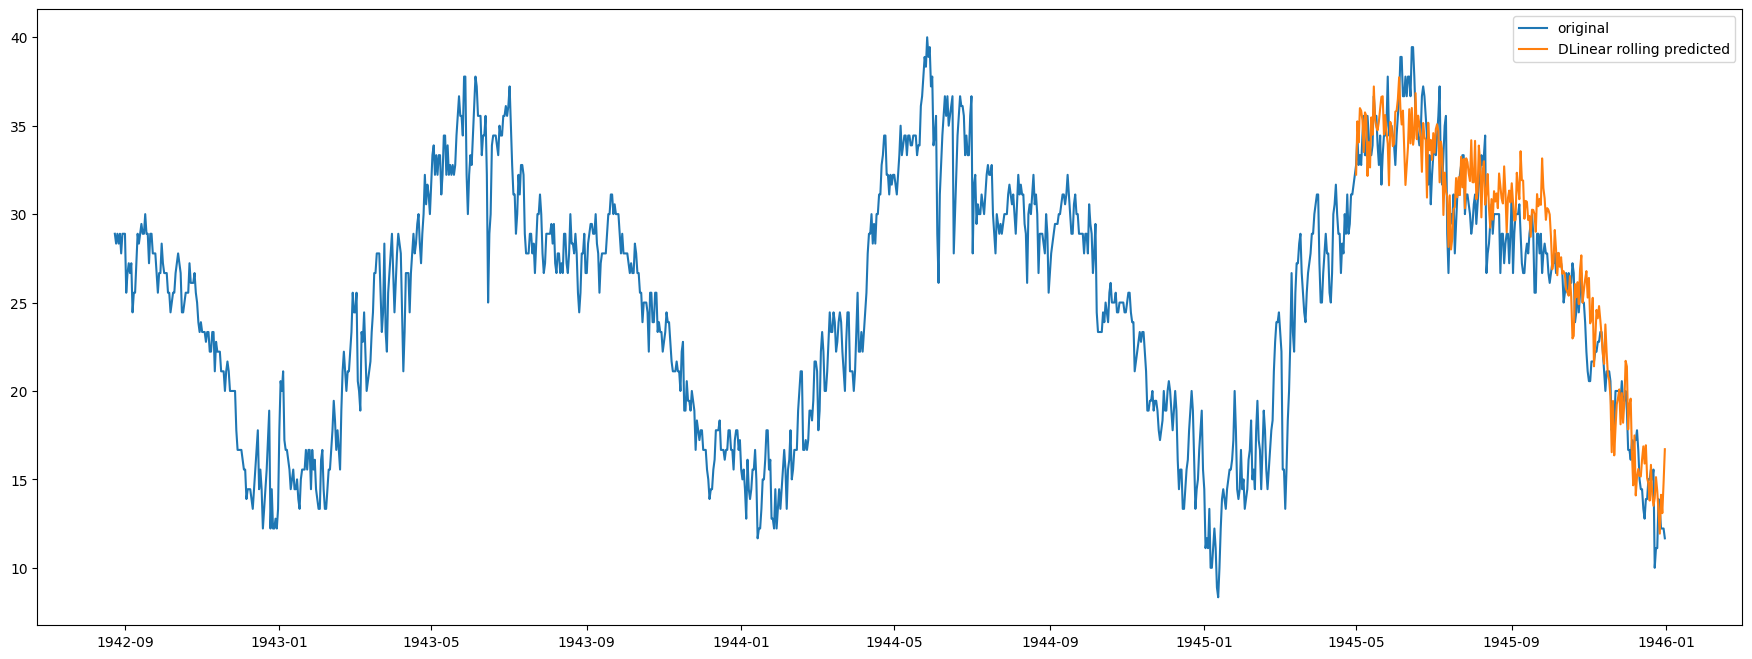

In [55]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [56]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,88.112,0.944,2.38,7.49


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [ ]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

In [ ]:
어렵다...